In [2]:
%load_ext autoreload
%autoreload 2

from common.config import JsonConfig
from common import utils, metrics
from ffm_iql.builder import build 
from ffm_iql.evaluation import evaluate, sample_scanpaths


import numpy as np
import pandas as pd
import torch
import random
import os 
from tqdm import tqdm 
import collections
import pprint

import matplotlib.pyplot as plt
from datetime import datetime
today = datetime.today().strftime('%Y%m%d')

device = torch.device('cuda:0')
# device = torch.device('cpu')
seed = 0
torch.manual_seed(seed)
np.random.seed(seed)
random.seed(seed)

# Load task setup and stimuli

In [7]:
# TAP='TP' 
TAP='TPtoTA'

In [8]:
#dataset_root = '/home/young/hdd1/coco-search18/'
dataset_root = '/data/datasets/coco-search18-IRL/'
hparams = JsonConfig('./configs/coco_search18_eDCB_IQL_TP_LIOR.json')
# hparams = JsonConfig('./configs/coco_search18_eDCB_IQL_TA_LIOR.json')


hparams_tp = JsonConfig('./configs/coco_search18_TP.json')
hparams_ta = JsonConfig('./configs/coco_search18_TA.json')
hparams_fv = JsonConfig('./configs/coco_search18_FV.json')

if TAP=='TPtoTA':
    # change hparam to TA setup
    hparams_ta_training = JsonConfig('./configs/coco_search18_eDCB_IQL_TA_LIOR.json')
    maxtrajcopy = hparams.Data.max_traj_length
    hparams.Data = hparams_ta_training.Data
    hparams.Data.max_traj_length =maxtrajcopy
    hparams_ta.Data.max_traj_length =maxtrajcopy
    TAP='TA'
    
# hparams.Data.sem_seq_dir = 'semantic_seq_stuffthing/'

# build model
agent, train_gaze_loader, train_img_loader, valid_img_loader,\
    valid_img_loader_ta, valid_img_loader_fv, env, env_valid, global_step, bbox_annos,\
    human_cdf, fix_clusters, prior_maps_tp, prior_maps_ta, prior_maps_fv,\
    sss_strings, valid_gaze_loader_tp, valid_gaze_loader_ta, valid_gaze_loader_fv,\
    sps_test_tp, sps_test_ta, sps_test_fv = build(
        hparams, dataset_root, device, load_coco_annos=False)


max_len = hparams.Data.max_traj_length

print(f'scanpath truncated at max length: {max_len}')

# fix_clusters = np.load(f'{dataset_root}/clusters.npy',
#                                allow_pickle=True).item()
# for k, v in fix_clusters.items():
#     if isinstance(v['strings'], list):
#         break
#     # remove other subjects' data if "subject" is specified
#     if hparams.Data.subject > -1:
#         try:
#             v['strings'] = [v['strings'][hparams.Data.subject]]
#         except:
#             v['strings'] = []
#     else:
#         v['strings'] = list(v['strings'].values())

# get unique task - img pair for analysis
if TAP == 'TP':
    valid_dataset = valid_img_loader.dataset
elif TAP == 'TA':
    valid_dataset = valid_img_loader_ta.dataset

valid_task_img_pair = np.unique([
    img['cat_name'] + '_' + img['img_name'] 
    for img in list(valid_dataset)
])
print(f'len: {len(valid_task_img_pair)}')

# validation fixation data
# valid_target_trajs = list(filter(lambda x: x['split'] == 'test', target_trajs))

# # generate task-image-pair
# TAP='TP'
# if TAP=='TP':
#     valid_target_trajs = sps_test_tp
# elif TAP=='TA':
#     valid_target_trajs = sps_test_ta
# elif TAP=='FV':
#     valid_target_trajs = sps_test_fv
# else:
#     raise NotImplementedError
    
# get unique task - img pair for analysis
# valid_task_img_pair = np.unique([
#     traj['task'] + '_' + traj['name'] #+ '_' + traj['condition']
#     for traj in valid_target_trajs
# ])
# print('len:', len(valid_task_img_pair))
# np.save(f'test_{TAP}_task_img_pair.npy', valid_task_img_pair)
# print('save to disk')


# using DCB dataset: COCO-Search18 TAP: TP
# average train scanpath length : 3.637 (+/-1.850)
# num of train trajs = 18961
# average valid scanpath length : 3.620 (+/-1.782)
# num of valid trajs = 5424
# target fixation prob (valid).: [0.00847614 0.46334244 0.80982789 0.93608998 0.97351685 0.9874683 ]
# num of training and eval fixations = 35856, 9974
# num of training and eval images = 2163, 612 (TP), 612 (TA), 0(FV)
# num of training batches = 1120
# loaded weights from ./pretrained/ckp_temporal_TP.pt.
# scanpath truncated at max length: 6
# len: 612

# using DCB dataset: COCO-Search18 TAP: TA
# average train scanpath length : 5.836 (+/-4.035)
# num of train trajs = 21627
# average valid scanpath length : 5.852 (+/-4.208)
# num of valid trajs = 6120
# target fixation prob (valid).: [0.00847614 0.46334244 0.80982789 0.93608998 0.97351685 0.9874683 ]
# num of training and eval fixations = 104597, 29694
# num of training and eval images = 2163, 612 (TP), 612 (TA), 0(FV)
# num of training batches = 3268
# loaded weights from ./pretrained/ckp_temporal_TP.pt.
# scanpath truncated at max length: 6
# len: 612

using DCB dataset: COCO-Search18 TAP: TA
average train scanpath length : 5.836 (+/-4.035)
num of train trajs = 21627
average valid scanpath length : 5.852 (+/-4.208)
num of valid trajs = 6120
target fixation prob (valid).: [0.00847614 0.46334244 0.80982789 0.93608998 0.97351685 0.9874683 ]
num of training and eval fixations = 104597, 29694
num of training and eval images = 2163, 612 (TP), 612 (TA), 0(FV)
num of training batches = 3268
loaded weights from ./pretrained/ckp_temporal_TP.pt.
scanpath truncated at max length: 6
len: 612


In [ ]:
# # test1 = np.load('/home/young/hdd1/coco-search18/semantic_seq_full/test.pkl', allow_pickle=True)
# # test2 = np.load('/home/young/hdd1/coco-search18/semantic_seq_stuffthing/test.pkl', allow_pickle =True)

# import pickle
# testTA = np.load('/home/young/hdd1/coco-search18/semantic_seq_stuffthing/test_TA_Sem.pkl', allow_pickle=True)
# testTP = np.load('/home/young/hdd1/coco-search18/semantic_seq_stuffthing/test_TP_Sem.pkl', allow_pickle =True)
# test = {}
# test.update(testTA)
# test.update(testTP)

# for key_stimuli, scanpath_stimuli in test.items():
#     scanpathlist=[]
#     for scanpath in scanpath_stimuli:
#         fixationlist = []
#         for fixation, duration in scanpath:
#             fixationlist.append(fixation)
#         scanpathlist.append(fixationlist)
#     test[key_stimuli] = scanpathlist
    
# # np.save('/home/young/hdd1/coco-search18/semantic_seq_stuffthing/test.pkl', test, allow_pickle=True)
# with open('/home/young/hdd1/coco-search18/semantic_seq_stuffthing/test.pkl', 'wb') as file:
#     pickle.dump(test, file)
# print('file merged and saved to the disk')

# evaluate reward map

In [ ]:
# code modified from evalaute in evaluation.py
env = env_valid
model = agent
log_dir = './' # None
def run_evaluation():
    rst_tp, rst_ta, rst_fv = None, None, None
    if hparams.Data.TAP in ['TP', 'TAP']:
        rst_tp = evaluate(
            env_valid,
            agent,
            valid_img_loader,
            valid_gaze_loader_tp,
            hparams_tp.Data,
            bbox_annos,
            human_cdf,
            fix_clusters,
            prior_maps_tp,
            sss_strings,
            dataset_root,
            sps_test_tp,
            sample_action=False,
            sample_scheme='Greedy',
            log_dir=log_dir ,
            save_visualization=False,
        )
        print("TP:", rst_tp)
    if hparams.Data.TAP in ['TA', 'TAP']:
        rst_ta = evaluate(
            env_valid,
            agent,
            valid_img_loader_ta,
            valid_gaze_loader_ta,
            hparams_ta.Data,
            bbox_annos,
            human_cdf,
            fix_clusters,
            prior_maps_ta,
            sss_strings,
            dataset_root,
            sps_test_ta,
            sample_action=False,
            sample_scheme='Greedy',
            log_dir=log_dir ,
            save_visualization=False,
        )
        print("TA", rst_ta)
    if hparams.Data.TAP in ['FV', 'ALL']:
        rst_fv = evaluate(
            env_valid,
            agent,
            valid_img_loader_fv,
            valid_gaze_loader_fv,
            hparams_fv.Data,
            bbox_annos,
            human_cdf,
            fix_clusters,
            prior_maps_fv,
            sss_strings,
            dataset_root,
            sps_test_fv,
            sample_action=False,
            sample_scheme='Greedy',
            log_dir=log_dir ,
            save_visualization=False,
        )
        print("FV", rst_fv)
    return rst_tp, rst_ta, rst_fv

our_metrics = run_evaluation()
# print(metrics)
pprint.pprint(our_metrics )



# using DCB dataset: COCO-Search18 TAP: TP
# average train scanpath length : 3.637 (+/-1.850)
# num of train trajs = 18961
# average valid scanpath length : 3.620 (+/-1.782)
# num of valid trajs = 5424
# target fixation prob (valid).: [0.00847614 0.46334244 0.80982789 0.93608998 0.97351685 0.9874683 ]
# Generating scanapths...
#   0%|          | 0/20 [00:00<?, ?it/s]
# 100%|██████████| 20/20 [00:02<00:00,  7.11it/s]
# Computing metrics...
# 100%|██████████| 312/312 [00:06<00:00, 49.51it/s]
# TP: {'Greedy_TFP_top1': 0.5802142824536466, 'Greedy_TFP_top2': 0.6208014740787066, 'Greedy_TFP_top3': 0.6743576321778754, 'Greedy_TFP_top4': 0.7077414705617135, 'Greedy_TFP_top5': 0.7243877166329246, 'Greedy_TFP-AUC': 3.307502575904867, 'Greedy_prob_mismatch': 1.1049627070142454, 'Greedy_TP_seq_score_max': 0.41947594524014375, 'Greedy_TP_seq_score_2steps': 0.49398148148148147, 'Greedy_TP_seq_score_4steps': 0.43308369644153955, 'Greedy_TP_seq_score_6steps': 0.4222621641249092, 'Greedy_TP_semantic_seq_score_max': 0.49028796042189166, 'Greedy_TP_semantic_seq_score_2steps': 0.5516249092229484, 'Greedy_TP_semantic_seq_score_4steps': 0.5104892883079157, 'Greedy_TP_semantic_seq_score_6steps': 0.4912518155410312, 'Greedy_TP_cIG': 0.9385099211179628, 'Greedy_TP_cNSS': 3.116828441619873, 'Greedy_TP_cAUC': 0.9405767321586609}
# ({'Greedy_TFP-AUC': 3.307502575904867,
#   'Greedy_TFP_top1': 0.5802142824536466,
#   'Greedy_TFP_top2': 0.6208014740787066,
#   'Greedy_TFP_top3': 0.6743576321778754,
#   'Greedy_TFP_top4': 0.7077414705617135,
#   'Greedy_TFP_top5': 0.7243877166329246,
#   'Greedy_TP_cAUC': 0.9405767321586609,
#   'Greedy_TP_cIG': 0.9385099211179628,
#   'Greedy_TP_cNSS': 3.116828441619873,
#   'Greedy_TP_semantic_seq_score_2steps': 0.5516249092229484,
#   'Greedy_TP_semantic_seq_score_4steps': 0.5104892883079157,
#   'Greedy_TP_semantic_seq_score_6steps': 0.4912518155410312,
#   'Greedy_TP_semantic_seq_score_max': 0.49028796042189166,
#   'Greedy_TP_seq_score_2steps': 0.49398148148148147,
#   'Greedy_TP_seq_score_4steps': 0.43308369644153955,
#   'Greedy_TP_seq_score_6steps': 0.4222621641249092,
#   'Greedy_TP_seq_score_max': 0.41947594524014375,
#   'Greedy_prob_mismatch': 1.1049627070142454},
#  None,
#  None)


# Generating scanapths...
#   0%|          | 0/20 [00:00<?, ?it/s]
# 100%|██████████| 20/20 [00:01<00:00, 11.19it/s]
# Computing metrics...
# 100%|██████████| 928/928 [00:17<00:00, 52.91it/s]
# TA {'Greedy_TA_seq_score_max': 0.3100334937216229, 'Greedy_TA_seq_score_2steps': 0.5322712418300654, 'Greedy_TA_seq_score_4steps': 0.39052287581699346, 'Greedy_TA_seq_score_6steps': 0.3371459694989106, 'Greedy_TA_semantic_seq_score_max': 0.3346055070449681, 'Greedy_TA_semantic_seq_score_2steps': 0.5341503267973857, 'Greedy_TA_semantic_seq_score_4steps': 0.42479575163398686, 'Greedy_TA_semantic_seq_score_6steps': 0.36171023965141613, 'Greedy_TA_cIG': -2.4448897019177034, 'Greedy_TA_cNSS': 1.0402865409851074, 'Greedy_TA_cAUC': 0.900560736656189}
# (None,
#  {'Greedy_TA_cAUC': 0.900560736656189,
#   'Greedy_TA_cIG': -2.4448897019177034,
#   'Greedy_TA_cNSS': 1.0402865409851074,
#   'Greedy_TA_semantic_seq_score_2steps': 0.5341503267973857,
#   'Greedy_TA_semantic_seq_score_4steps': 0.42479575163398686,
#   'Greedy_TA_semantic_seq_score_6steps': 0.36171023965141613,
#   'Greedy_TA_semantic_seq_score_max': 0.3346055070449681,
#   'Greedy_TA_seq_score_2steps': 0.5322712418300654,
#   'Greedy_TA_seq_score_4steps': 0.39052287581699346,
#   'Greedy_TA_seq_score_6steps': 0.3371459694989106,
#   'Greedy_TA_seq_score_max': 0.3100334937216229},
#  None)

# Generate model scanpaths and reward maps 

In [ ]:
# code modified from evalaute in evaluation.py
env = env_valid
model = agent

    
if hparams.Data.TAP == 'TP':
    dataloader = valid_img_loader # train_img_loader for using training image
    pa= hparams_tp.Data
#     pa['enforce_IOR'] = False
#     print(pa)
if hparams.Data.TAP == 'TA':
    dataloader =  valid_img_loader_ta
    pa= hparams_ta.Data
#     pa['enforce_IOR'] = False

model.eval()


scanpaths, visualizations = sample_scanpaths(env, model, dataloader, pa,
                                             sample_action=False, 
                                             sample_scheme='Greedy', # this is not necessary
                                             sample_stop=False,
                                             save_visualization=True)

# Test model performance

In [ ]:
# # code modified from evalaute in evaluation.py
# # insert log_dir for saving visualizations

# env = env_valid
# model = agent

# def run_evaluation():
#     rst_tp, rst_ta, rst_fv = None, None, None
#     if hparams.Data.TAP in ['TP', 'TAP']:
#         rst_tp = evaluate(
#             env_valid,
#             agent,
#             valid_img_loader,
#             valid_gaze_loader_tp,
#             hparams_tp.Data,
#             bbox_annos,
#             human_cdf,
#             fix_clusters,
#             prior_maps_tp,
#             sss_strings,
#             dataset_root,
#             sps_test_tp,
#             sample_action=False,
#             sample_scheme='Greedy',
#             log_dir=None,
#             save_visualization=False,
#         )
#         print("TP:", rst_tp)
#     if hparams.Data.TAP in ['TA', 'TAP']:
#         rst_ta = evaluate(
#             env_valid,
#             agent,
#             valid_img_loader_ta,
#             valid_gaze_loader_ta,
#             hparams_ta.Data,
#             bbox_annos,
#             human_cdf,
#             fix_clusters,
#             prior_maps_ta,
#             sss_strings,
#             dataset_root,
#             sps_test_ta,
#             sample_action=False,
#             sample_scheme='Greedy',
#             log_dir=None,
#             save_visualization=False,
#         )
#         print("TA", rst_ta)
#     if hparams.Data.TAP in ['FV', 'ALL']:
#         rst_fv = evaluate(
#             env_valid,
#             agent,
#             valid_img_loader_fv,
#             valid_gaze_loader_fv,
#             hparams_fv.Data,
#             bbox_annos,
#             human_cdf,
#             fix_clusters,
#             prior_maps_fv,
#             sss_strings,
#             dataset_root,
#             sps_test_fv,
#             sample_action=False,
#             sample_scheme='Greedy',
#             log_dir=None,
#             save_visualization=False,
#         )
#         print("FV", rst_fv)
#     return rst_tp, rst_ta, rst_fv

# metrics = run_evaluation()
# # print(metrics)]

# # generate categoriwise performance
# metric_columns = ['TFP', 'SS', 'SemSS', 'cIG', 'cNSS', 'cAUC', 'SPR']
# # metric_columns = ['SemSS', 'SS', 'cIG', 'cNSS', 'cAUC']

# dfs = []
# for i, cat in enumerate(CATEGORIES18:
#     df = pd.read_csv(f'results/DCBablation_SemSSupdated/metric_{cat}.csv')
#     dfs.append(df.iloc[0].to_frame().transpose().copy())
    
# alldf = pd.concat(dfs)[metric_columns]
# alldf['label'] = CATEGORIES18
# alldf.to_csv('results/TP_all_categories_SemSSupdated.csv', index=False)
# alldf

# compare with baselines 

In [ ]:
# # you can check the format of predictions here
# import numpy as np
# import matplotlib.pyplot as plt

# TAP = "TP"
# pfiles = [f'pred_{TAP}_random.npy', f'pred_{TAP}_IVSN.npy', 
#           f'pred_{TAP}_detection_hilow_aug.npy', None, f'pred_{TAP}_Gazeformer.npy', f'pred_{TAP}_HAT.npy']
# models = ['Random', 'IVSN', 'Foveated Detector', 'Reward Map', 'Gazeformer', 'HAT']
# pred = np.load(f'./baselines/{models[2]}/{pfiles[2]}', allow_pickle=True)
# pred = np.load(f'./baselines/{models[-1]}/{pfiles[-1]}', allow_pickle=True)

# # pred = np.load(f'./baselines/{models[0]}/{pfiles[0]}', allow_pickle=True)

# # array([{'name': '000000288161.jpg', 'task': 'sink', 'X': [256, 112.0, 112.0, 80.0, 144.0, 80.0, 304.0], 'Y': [160, 208.0, 240.0, 208.0, 208.0, 240.0, 208.0], 'length': 7

# for map in pred[1]['attn_map']:
#     plt.imshow(map)
#     plt.show()

# # xs = [len(p['attn_map']) for p in pred]
# # np.unique(xs)

In [9]:
# TAP='TP'
TAP='TA'

USE_PRECOMPUTED = True
pfiles = [None, 
          f'pred_{TAP}_random_wid.npy', 
          f'pred_{TAP}_IVSN.npy', 
          f'pred_{TAP}_detection_hilow_aug.npy', 
          None, 
           f'pred_{TAP}_deepgaze3.npy',
          f'pred_{TAP}_Gazeformer.npy',
          None]
models = ['Human Consistency', 
          'Random', 
          'IVSN', 
          'Foveated Detector', 
          'Reward Map', 
          'DeepGaze3',
          'Gazeformer',
          'HAT']

# pfiles = [f'pred_{TAP}_random_wid.npy'] # 6120
# models = ['Random']

# pfiles = [f'pred_{TAP}_IVSN.npy'] #612
# models = ['IVSN']

# pfiles = [f'pred_{TAP}_detection_hilow_aug.npy'] #612
# models = ['Foveated Detector'] 
 
# # pfiles = [None]
# # models = ['Reward Map']

# pfiles = [f'pred_{TAP}_Gazeformer.npy'] # 6120
# models = ['Gazeformer']


# pfiles = [f'pred_{TAP}_deepgaze3.npy'] # 6120
# models = ['DeepGaze3']




# numbers pre-computed 
model_saliency_tp={}
model_saliency_tp['Human Consistency'] = {'SS':0.500, 'SemSS':0.530 , 'cIG': np.nan, 'cNSS': np.nan, 'cAUC':np.nan}
model_saliency_tp['Random'] = {'SS':0.278, 'SemSS':0.251, 'cIG': -0.932, 'cNSS':-0.0, 'cAUC':0.5}
model_saliency_tp['IVSN'] = {'SS': 0.337, 'SemSS':0.370, 'cIG': -0.329   , 'cNSS':1.285  , 'cAUC':0.899 }
model_saliency_tp['Foveated Detector'] = {'SS': 0.412, 'SemSS': 0.481, 'cIG': 1.060, 'cNSS': 2.751, 'cAUC': 0.932} 
model_saliency_tp['Reward Map'] = {'SS':0.422, 'SemSS':0.492, 'cIG': 0.939, 'cNSS': 3.117, 'cAUC':0.941}

model_saliency_tp['DeepGaze3'] = {'SS':0.319, 'SemSS':0.367, 'cIG': np.nan, 'cNSS': np.nan, 'cAUC':np.nan}
model_saliency_tp['Gazeformer'] = {'SS':0.479, 'SemSS':0.545, 'cIG': np.nan, 'cNSS': np.nan, 'cAUC':np.nan}
model_saliency_tp['HAT'] = {'SS':0.470, 'SemSS':0.543, 'cIG': 2.399, 'cNSS': 5.086, 'cAUC':0.977}
    


model_saliency_ta={}
model_saliency_ta['Human Consistency'] = {'SS':0.381, 'SemSS':0.410 , 'cIG': np.nan, 'cNSS': np.nan, 'cAUC':np.nan}
model_saliency_ta['Random'] = {'SS':0.305, 'SemSS':0.309, 'cIG': 0.627  , 'cNSS':-0.0   , 'cAUC':0.5  }
model_saliency_ta['IVSN'] = {'SS':0.307, 'SemSS':0.337,'cIG': -0.198 , 'cNSS': 0.895 , 'cAUC': 0.869 }
model_saliency_ta['Foveated Detector'] = {'SS':0.286, 'SemSS':0.310,'cIG': -0.622, 'cNSS': 0.657 , 'cAUC': 0.843}
model_saliency_ta['Reward Map'] = {'SS':0.337, 'SemSS':0.371, 'cIG': -2.445, 'cNSS': 1.040, 'cAUC': 0.901}

model_saliency_ta['DeepGaze3'] = {'SS':0.294, 'SemSS':0.325, 'cIG': np.nan, 'cNSS': np.nan, 'cAUC':np.nan}
model_saliency_ta['Gazeformer'] = {'SS':0.378, 'SemSS':0.388, 'cIG': np.nan, 'cNSS': np.nan, 'cAUC':np.nan}
model_saliency_ta['HAT'] = {'SS':0.358, 'SemSS':0.364, 'cIG': 0.717, 'cNSS': 1.910, 'cAUC':0.926}


#######
print('TAP', TAP)

cmpf = pd.DataFrame()
cmpf['model'] = models

SemSS = []
SS= []
CIG =[]
CNSS =[]
CAUC =[]

for pfilename, modelname in zip(pfiles, models):
    print('\n======== generating metrics for', modelname)

    if USE_PRECOMPUTED:
        if TAP=='TP':
            model_saliency=model_saliency_tp
        elif TAP=='TA':
            model_saliency = model_saliency_ta
        
        print('used pre-computed metrics')
        SS.append(model_saliency[modelname]['SS'])
        SemSS.append(model_saliency[modelname]['SemSS'])
        CIG.append(model_saliency[modelname]['cIG'])
        CNSS.append(model_saliency[modelname]['cNSS'])
        CAUC.append(model_saliency[modelname]['cAUC'])

        continue

    if modelname == 'Human Consistency': # always use precomputed ones
        SS.append(model_saliency[modelname]['SS'])
        SemSS.append(model_saliency[modelname]['SemSS'])
        CIG.append(model_saliency[modelname]['cIG'])
        CNSS.append(model_saliency[modelname]['cNSS'])
        CAUC.append(model_saliency[modelname]['cAUC'])

    if modelname == 'Reward Map':
        if TAP=='TP':
            om = our_metrics[0]
            SemSS.append(om['Greedy_TP_semantic_seq_score_6steps'])
            SS.append(om['Greedy_TP_seq_score_6steps']) # max is where truncate_gt=False
            CIG.append(om['Greedy_TP_cIG'])
            CNSS.append(om['Greedy_TP_cNSS'])
            CAUC.append(om['Greedy_TP_cAUC'])
        elif TAP=='TA':
            om = our_metrics[1]
            SemSS.append(om['Greedy_TA_semantic_seq_score_6steps'])
            SS.append(om['Greedy_TA_seq_score_6steps']) # max is where truncate_gt=False
            CIG.append(om['Greedy_TA_cIG'])
            CNSS.append(om['Greedy_TA_cNSS'])
            CAUC.append(om['Greedy_TA_cAUC'])            
        
    else:
        pred = np.load(f'./baselines/{modelname}/{pfilename}', allow_pickle=True)
        if 'repeat_id' in pred[0].keys():
            print('use only first repeat')
            pred = [sp for sp in pred if sp['repeat_id'] == 1] # only get the first repeat
        assert len(pred) == 612 # for TA and TP
        attn_maps = collections.defaultdict(dict)
        val_pred = []
        for sp in pred:
            new = {}
            try:
                task_img_pair= '_'.join([sp['task'].replace('_', ' '), sp['name']])
            except:
                task_img_pair= '_'.join([sp['task'].replace('_', ' '), sp['img_names']]) 
                sp['name'] = sp['img_names']

            if  task_img_pair in valid_task_img_pair:
                sp['task'] = sp['task'].replace('_', ' ')
                sp['condition'] = 'present' if TAP == 'TP' else 'absent'
                val_pred.append(sp)
                if 'attn_map' in sp.keys():
                    attn_maps[sp['task']][sp['name']] = sp.pop('attn_map') 
            else:
                print(task_img_pair, 'not exist')

        if TAP == 'TP':
            utils.cutFixOnTarget(val_pred, bbox_annos)
        print(f'# of valid pred scanpaths: {len(val_pred)}')
        

        # get sequence scores
        ss = metrics.get_seq_score(val_pred, fix_clusters, max_step=max_len, truncate_gt=True)
        SS.append(ss)

        # get semantic sequence scores
        sss = metrics.get_semantic_seq_score(
            val_pred, sss_strings, max_len, 
            f'{dataset_root}/{hparams.Data.sem_seq_dir}/segmentation_maps', truncate_gt=True)
        SemSS.append(sss)
    
        # Get conditional metrics 
        # Note that baseline don't have conditional/dynamic changes in the state 
        # so we used the static attn prob maps to calculate the metrics 
        if modelname == 'Foveated Detector':
            # foveated detector you can compute the metrics with actual fixations, use pre-computed numbers
            CIG.append(model_saliency[modelname]['cIG'])
            CNSS.append(model_saliency[modelname]['cNSS'])
            CAUC.append(model_saliency[modelname]['cAUC'])
        elif len(attn_maps)==0:
            print('no attn maps for', modelname)
            CIG.append(np.nan)
            CNSS.append(np.nan)
            CAUC.append(np.nan)
        else:
            # other models use the attn maps to compute the metrics (but their maps are not truly conditional on previous fixations)
            if TAP == 'TP':
                dl = valid_gaze_loader_tp
                task_dep_prior_maps = prior_maps_tp
            else:
                dl = valid_gaze_loader_ta
                task_dep_prior_maps = prior_maps_ta

            n_samples, info_gain, nss, auc = 0, 0, 0, 0
            pa = hparams.Data

            for batch in tqdm(dl, desc='Computing saliency metrics'):
                gt_next_fixs = (batch['next_normalized_fixations'][:, -1] * torch.tensor(
                    [pa.im_w, pa.im_h])).to(torch.long) # last item is always the next fixation, scanpath history + next fixation
                is_last = batch['is_last']
                non_term_mask = torch.logical_not(is_last)
                gt_next_fixs = gt_next_fixs[non_term_mask]

                probs = torch.stack([torch.from_numpy(attn_maps[task][name]) for task, name in zip(batch['task_name'], batch['img_name'])])
                probs = torch.nn.functional.interpolate(
                    probs.unsqueeze(1), size=(pa.im_h, pa.im_w), mode='bilinear').squeeze(1) 
                probs /= probs.sum(dim=-1, keepdim=True).sum(dim=-2, keepdim=True)
                probs = probs[non_term_mask]

                prior_maps = torch.stack([task_dep_prior_maps[task] for task in batch['task_name']])
                prior_maps = prior_maps[non_term_mask].cpu()


                if len(probs) == 0:
                    continue

                info_gain += metrics.compute_info_gain(probs, gt_next_fixs, prior_maps)
                nss += metrics.compute_NSS(probs, gt_next_fixs)
                auc += metrics.compute_cAUC(probs, gt_next_fixs) 
                n_samples += gt_next_fixs.size(0)
                
            CIG.append(info_gain.item() / n_samples)
            CNSS.append(nss.item() / n_samples)
            CAUC.append(auc.item() / n_samples)

#             print("cIG: {:.3f} & cNSS: {:.3f} & cAUC: {:.3f}".format(info_gain.item() / n_samples, 
#                                                     nss.item() / n_samples, 
#                                                     auc.item() / n_samples))


cmpf['SS'] = SS
cmpf['SemSS'] = SemSS
cmpf['cIG'] = CIG
cmpf['cNSS'] = CNSS
cmpf['cAUC'] = CAUC

columns = ['model', 'SS', 'SemSS', 'cNSS', 'cAUC', 'cIG']
cmpf= cmpf[columns]
display(round(cmpf,3))

TAP TA

======== generating metrics for Human Consistency
used pre-computed metrics

======== generating metrics for Random
used pre-computed metrics

======== generating metrics for IVSN
used pre-computed metrics

======== generating metrics for Foveated Detector
used pre-computed metrics

======== generating metrics for Reward Map
used pre-computed metrics

======== generating metrics for DeepGaze3
used pre-computed metrics

======== generating metrics for Gazeformer
used pre-computed metrics

======== generating metrics for HAT
used pre-computed metrics


,model,SS,SemSS,cNSS,cAUC,cIG
0,Human Consistency,0.381,0.410,NaN,NaN,NaN
1,Random,0.305,0.309,-0.000,0.500,0.627
2,IVSN,0.307,0.337,0.895,0.869,-0.198
3,Foveated Detector,0.286,0.310,0.657,0.843,-0.622
4,Reward Map,0.337,0.371,1.040,0.901,-2.445
5,DeepGaze3,0.294,0.325,NaN,NaN,NaN
6,Gazeformer,0.378,0.388,NaN,NaN,NaN
7,HAT,0.358,0.364,1.910,0.926,0.717


In [10]:
# add human consistency explained (in percetage) (score/human consistency) for SS and SemSS
human_SS = cmpf.loc[cmpf['model'] == 'Human Consistency', 'SS'].values[0]
human_SemSS = cmpf.loc[cmpf['model'] == 'Human Consistency', 'SemSS'].values[0]

# Compute % of human consistency explained
cmpf['SS_%human'] = (cmpf['SS'] / human_SS * 100).round(3)
cmpf['SemSS_%human'] = (cmpf['SemSS'] / human_SemSS * 100).round(3)

# save results
save_filepath = f'./results/{TAP}_model_comparison_{today}.csv'
cmpf.to_csv(save_filepath, index=False)
print('saved to', save_filepath)

# save table for latex
columns = ['model', 'SS', 'SemSS', 'cNSS',  'cAUC', 'cIG']
df_latex = cmpf[columns]

# Convert to LaTeX tabular format
latex_table = df_latex.to_latex(index=False, float_format="%.3f", na_rep="--", column_format="lrrrrr")


# Save to a .txt file
with open(f"./results/savefig/{TAP}_model_metrics_table_{today}.txt", "w") as f:
    f.write(latex_table)

saved to ./results/TA_model_comparison_20250829.csv


# model comparison plot

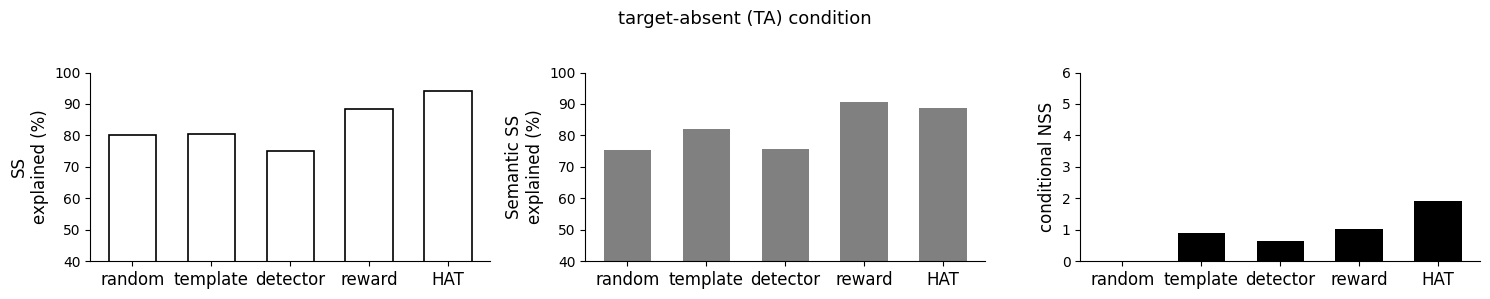

In [5]:
METRICS = ['SS_%human', 'SemSS_%human', 'cNSS']
SAVE_PLOT = True
TAP='TA'
df = pd.read_csv(f'./results/{TAP}_model_comparison_20250829.csv')

new_order = ['Random', 'IVSN', 'Foveated Detector', 'Reward Map', 'HAT']
df = df[df['model'].isin(new_order)]
df['order'] = df['model'].apply(lambda x: new_order.index(x))
df = df.sort_values('order').reset_index(drop=True)

FONTSIZE = 12
bar_width = 0.6
colors = ['blue', 'gray', 'black']

replace_dict = {'IVSN': 'Template', 
                'Foveated Detector': 'Detector', 
                'Reward Map': 'Reward'}
display_names = df['model'].replace(replace_dict).tolist()
display_names = [name.lower() if name != 'HAT' else name for name in display_names]
labels = ['\n'.join(label.split(' ')) for label in display_names]
x_values = np.arange(len(labels))

fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 3), sharex=False)

# --- 1st plot ---
ax1.bar(
    x_values, 
    df[METRICS[0]].values, 
    width=bar_width, 
    facecolor='white',   # fill color
    edgecolor='black',   # outline color
    linewidth=1.2        # optional: thickness of outline
)
ax1.set_xticks(x_values)
ax1.set_xticklabels(labels, fontsize=FONTSIZE)
ax1.set_ylabel('SS\nexplained (%)', fontsize=FONTSIZE)
ax1.set_ylim(40, 100)
ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)

# --- 2nd plot ---
ax2.bar(x_values, df[METRICS[1]].values, width=bar_width, color=colors[1])
ax2.set_xticks(x_values)
ax2.set_xticklabels(labels, fontsize=FONTSIZE)
ax2.set_ylabel('Semantic SS\nexplained (%)', fontsize=FONTSIZE)
ax2.set_ylim(40, 100)
#ax2.set_title('cIG', fontsize=FONTSIZE)
# ax2.set_ylim(-1.5, 10)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

# --- 3rd plot ---
ax3.bar(x_values, df[METRICS[2]].values, width=bar_width, color=colors[2])
ax3.set_xticks(x_values)
ax3.set_xticklabels(labels, fontsize=FONTSIZE)
ax3.set_ylabel('conditional NSS', fontsize=FONTSIZE)
ax3.set_ylim(0, 6)
ax3.spines['top'].set_visible(False)
ax3.spines['right'].set_visible(False)


# Overall title
fig.suptitle('target-absent (TA) condition' if TAP == 'TA' else 'target-present (TP) condition', fontsize=FONTSIZE+1)

plt.tight_layout(rect=[0, 0, 1, 0.95])
if SAVE_PLOT:
    plt.savefig(f'results/savefig/{TAP}_metric_comparison_separate_{today}.png', dpi=300, bbox_inches='tight')
plt.show()

# archive nfix

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

# === CONFIG (TP only) ===
assert TAP == 'TP', "Average fixations-to-target is defined for TP only."
SAVE_DIR = Path('./results/savefig'); SAVE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR = Path('./results'); TABLE_DIR.mkdir(parents=True, exist_ok=True)

# Your lists
pfiles = [
    None,                                 # Human (skip file)
    'pred_TP_random_wid.npy',             # Random
    'pred_TP_IVSN.npy',                   # IVSN
    'pred_TP_detection_hilow_aug.npy',    # Foveated Detector
    None,                                 # Reward Map (no pred file; skip unless you have one)
    'pred_TP_HAT.npy'                     # HAT
]
models = ['Human', 'Random', 'IVSN', 'Foveated Detector', 'Reward Map', 'HAT']

# Colors (yours)
color_map = {
    'Human': '#DAA520',              # goldenrod
    'Reward Map': '#0015B2',         # blue (ours)
    'Foveated Detector': '#696966',  # gray
    'HAT': '#000000',                # black
    'IVSN': '#198754',               # green-ish
    'Random': '#A020F0',             # purple
}

# ---------- Utils ----------
def load_human_scanpaths(split, TAP, dataset_root='/data/datasets/coco-search18-IRL/'):
    fixation_path = dataset_root + 'coco_search_fixations_512x320_on_target_allvalid.json'
    with open(fixation_path) as json_file:
        human_all = json.load(json_file)
    if TAP == 'TP':
        human = [x for x in human_all if x['condition']=='present' and x['split']==split]
    else:
        human = [x for x in human_all if x['condition']=='absent' and x['split']==split]
    for sp in human:
        sp['X'][0], sp['Y'][0] = 256, 160  # center correction
    return human


def normalize_reward_scanpaths(scanpaths, valid_task_img_pair, tap='TP'):
    """
    Convert your Reward model scanpaths (from sample_scanpaths) into the
    same normalized list we use elsewhere. Filters to valid task_img pairs.
    """
    out = []
    for sp in scanpaths:
        task = sp['task'].replace('_', ' ')
        name = sp['name']
        key = f"{task}_{name}"
        if key not in valid_task_img_pair:
            continue
        sp2 = {
            'task': task,
            'name': name,
            'condition': 'present' if tap == 'TP' else 'absent',
            # X/Y might already be np arrays; ensure list-like for consistency
            'X': np.asarray(sp['X']).tolist(),
            'Y': np.asarray(sp['Y']).tolist(),
        }
        out.append(sp2)
    return out

def steps_to_target(X, Y, bbox):
    """
    Return 1-based index of first fixation inside bbox, else np.nan.
    bbox = [x, y, w, h]; X/Y are pixel coords (list/array).
    """
    X = np.asarray(X); Y = np.asarray(Y)
    inside_x = (X > bbox[0]) & (X < bbox[0] + bbox[2])
    inside_y = (Y > bbox[1]) & (Y < bbox[1] + bbox[3])
    on_target = inside_x & inside_y
    if np.any(on_target):
        return int(np.argmax(on_target) + 1)  # 1-based
    return np.nan

def summarize_fixations(step_list):
    """Compute n, mean, se, median for successful trials (ignore NaN)."""
    steps = np.array(step_list, dtype=float)
    hits = steps[~np.isnan(steps)]
    n = len(hits)
    mean = float(np.nanmean(hits)) if n > 0 else np.nan
    se = float(np.nanstd(hits, ddof=1) / np.sqrt(n)) if n > 1 else np.nan
    median = float(np.nanmedian(hits)) if n > 0 else np.nan
    return dict(n=n, mean=mean, se=se, median=median)
def normalize_and_filter_preds(pred_array, valid_task_img_pair):
    """Make (task, name) consistent, TP tag, and keep only valid task_img pairs."""
    out = []
    for sp in pred_array:
        task = sp['task'].replace('_', ' ')
        name = sp['name'] if 'name' in sp else sp.get('img_names')
        if name is None:
            continue
        sp = sp.copy()
        sp['task'] = task
        sp['name'] = name
        sp['condition'] = 'present'
        key = f"{task}_{name}"
        if key in valid_task_img_pair:
            out.append(sp)
    return out


# ---------- Collect per-trial steps-to-target for each model ----------
per_model_steps = {}

# Human (unchanged)
print('Processing Human...')
human_scanpaths = load_human_scanpaths(split='test', TAP=TAP, dataset_root=dataset_root)
human_val = []
for sp in human_scanpaths:
    task = sp['task'].replace('_', ' ')
    key = f"{task}_{sp['name']}"
    if key in valid_task_img_pair:
        # keep only correct+fixOnTarget (consistent with your prior usage)
        if sp.get('correct', False) and sp.get('fixOnTarget', False):
            sp2 = sp.copy(); sp2['task'] = task; human_val.append(sp2)

human_steps = []
for sp in human_val:
    key = f"{sp['task']}_{sp['name']}"
    bbox = bbox_annos.get(key)
    human_steps.append(steps_to_target(sp['X'], sp['Y'], bbox) if bbox is not None else np.nan)
per_model_steps['Human'] = human_steps
print(f'Human N={len(human_steps)}')

# --- NEW: Reward model from your in-memory scanpaths ---
# Requires: `scanpaths` already computed via sample_scanpaths(...)
print('Processing Reward Map...')
reward_val = normalize_reward_scanpaths(scanpaths, valid_task_img_pair, tap=TAP)
reward_steps = []
for sp in reward_val:
    key = f"{sp['task']}_{sp['name']}"
    bbox = bbox_annos.get(key)
    reward_steps.append(steps_to_target(sp['X'], sp['Y'], bbox) if bbox is not None else np.nan)
per_model_steps['Reward Map'] = reward_steps
print(f'Reward Map N={len(reward_steps)}')

# Models from files (unchanged)
for pfilename, modelname in zip(pfiles, models):
    if modelname in ['Human', 'Reward Map']:  # Human handled above; Reward handled from memory
        continue
    print(f'Processing {modelname}...')
    pred = np.load(f'./baselines/{modelname}/{pfilename}', allow_pickle=True)
    if isinstance(pred, (list, np.ndarray)) and len(pred)>0 and isinstance(pred[0], dict):
        if 'repeat_id' in pred[0].keys():
            pred = [sp for sp in pred if sp.get('repeat_id', 1) == 1]
    val_pred = normalize_and_filter_preds(pred, valid_task_img_pair)
    steps = []
    for sp in val_pred:
        key = f"{sp['task']}_{sp['name']}"
        bbox = bbox_annos.get(key)
        steps.append(steps_to_target(sp['X'], sp['Y'], bbox) if bbox is not None else np.nan)
    per_model_steps[modelname] = steps
    print(f'{modelname} N={len(steps)}')
# ---------- Summary/plot ----------
rows = []
order = ['Human', 'Reward Map', 'Foveated Detector', 'HAT', 'IVSN', 'Random']
for m in [mm for mm in order if mm in per_model_steps]:
    stats_m = summarize_fixations(per_model_steps[m])
    rows.append({'model': m, **stats_m})

df_summary = pd.DataFrame(rows)
df_summary['model'] = pd.Categorical(df_summary['model'], categories=order, ordered=True)
df_summary = df_summary.sort_values('model').reset_index(drop=True)
print(df_summary)
df_summary.to_csv(TABLE_DIR / 'avg_fixations_to_target_summary.csv', index=False)

# ---------- Bar plot: Mean ± SE ----------
plt.figure(figsize=(6.5, 4.2))
x = np.arange(len(df_summary))
means = df_summary['mean'].values
ses = df_summary['se'].values
labels = df_summary['model'].astype(str).tolist()
bar_colors = [color_map.get(m, '#444444') for m in labels]

plt.bar(x, means, yerr=ses, capsize=4, linewidth=0.8, edgecolor='white', color=bar_colors)
plt.xticks(x, labels, rotation=0)
plt.ylabel('Fixations to Target (mean ± SE)')
plt.title(f'Average Fixations to Target — {TAP}')
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.4)
plt.tight_layout()
plt.savefig(SAVE_DIR / f'{TAP}_avg_fixations_to_target_bar.png', dpi=300)
plt.show()
plt.close()

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import json
from pathlib import Path

# ===== Assumptions / existing objects =====
# TAP == 'TP'
# valid_task_img_pair : set of "<task>_<imgname>"
# bbox_annos          : dict "<task>_<imgname>" -> [x, y, w, h]
# dataset_root        : base path for human json
# scanpaths           : Reward model scanpaths already computed (from sample_scanpaths)
# CATEGORIES18        : optional; list of 18 categories. If absent, inferred from data.

assert TAP == 'TP', "Per-category fixations-to-target is defined for TP only."

SAVE_DIR = Path('./results/savefig'); SAVE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR = Path('./results'); TABLE_DIR.mkdir(parents=True, exist_ok=True)

# File locations for baselines
pfiles = {
    'Foveated Detector': 'pred_TP_detection_hilow_aug.npy',
    'HAT':               'pred_TP_HAT.npy',
}

# Colors (consistent with your scheme)
color_map = {
    'Human': '#DAA520',              # goldenrod
    'Reward Map': '#0015B2',         # blue (ours)
    'Foveated Detector': '#696966',  # gray
    'HAT': '#000000',                # black
}

models_keep = ['Human', 'Reward Map', 'Foveated Detector', 'HAT']

# ---------- Helpers ----------
def load_human_scanpaths(split, TAP, dataset_root):
    fixation_path = dataset_root + 'coco_search_fixations_512x320_on_target_allvalid.json'
    with open(fixation_path) as f:
        human_all = json.load(f)
    if TAP == 'TP':
        human = [x for x in human_all if x['condition']=='present' and x['split']==split]
    else:
        human = [x for x in human_all if x['condition']=='absent' and x['split']==split]
    for sp in human:
        sp['X'][0], sp['Y'][0] = 256, 160
    return human

def steps_to_target(X, Y, bbox):
    """Return 1-based index of first fixation inside bbox, else np.nan."""
    if bbox is None: return np.nan
    X = np.asarray(X); Y = np.asarray(Y)
    inside_x = (X > bbox[0]) & (X < bbox[0] + bbox[2])
    inside_y = (Y > bbox[1]) & (Y < bbox[1] + bbox[3])
    on_target = inside_x & inside_y
    return int(np.argmax(on_target) + 1) if np.any(on_target) else np.nan

def summarize_steps(arr):
    """Mean ± SE over non-NaN hits, plus n."""
    hits = np.asarray(arr, float)
    hits = hits[~np.isnan(hits)]
    n = len(hits)
    mean = float(np.nanmean(hits)) if n>0 else np.nan
    se = float(np.nanstd(hits, ddof=1)/np.sqrt(n)) if n>1 else np.nan
    return mean, se, int(n)

def normalize_and_filter_preds(pred_array, valid_task_img_pair):
    out = []
    for sp in pred_array:
        task = sp['task'].replace('_', ' ')
        name = sp['name'] if 'name' in sp else sp.get('img_names')
        if name is None: continue
        key = f"{task}_{name}"
        if key in valid_task_img_pair:
            out.append({'task': task, 'name': name, 'X': sp['X'], 'Y': sp['Y']})
    return out

def normalize_reward_scanpaths(scanpaths, valid_task_img_pair):
    out = []
    for sp in scanpaths:
        task = sp['task'].replace('_', ' ')
        name = sp['name']
        key  = f"{task}_{name}"
        if key in valid_task_img_pair:
            out.append({'task': task, 'name': name, 'X': np.asarray(sp['X']).tolist(), 'Y': np.asarray(sp['Y']).tolist()})
    return out

# ---------- Collect per-trial steps per CATEGORY for each model ----------
per_model_cat_steps = {m: {} for m in models_keep}

# Human
print('Processing Human…')
human = load_human_scanpaths(split='test', TAP=TAP, dataset_root=dataset_root)
human_val = []
for sp in human:
    task = sp['task'].replace('_', ' ')
    key = f"{task}_{sp['name']}"
    if key in valid_task_img_pair and sp.get('correct', False) and sp.get('fixOnTarget', False):
        human_val.append({'task': task, 'name': sp['name'], 'X': sp['X'], 'Y': sp['Y']})

for sp in human_val:
    key = f"{sp['task']}_{sp['name']}"
    step = steps_to_target(sp['X'], sp['Y'], bbox_annos.get(key))
    per_model_cat_steps['Human'].setdefault(sp['task'], []).append(step)

# Reward Map (from in-memory scanpaths)
print('Processing Reward Map…')
reward_val = normalize_reward_scanpaths(scanpaths, valid_task_img_pair)
for sp in reward_val:
    key = f"{sp['task']}_{sp['name']}"
    step = steps_to_target(sp['X'], sp['Y'], bbox_annos.get(key))
    per_model_cat_steps['Reward Map'].setdefault(sp['task'], []).append(step)

# Baselines from files
for modelname, pfile in pfiles.items():
    print(f'Processing {modelname}…')
    pred = np.load(f'./baselines/{modelname}/{pfile}', allow_pickle=True)
    if isinstance(pred, (list, np.ndarray)) and len(pred)>0 and isinstance(pred[0], dict):
        if 'repeat_id' in pred[0]:
            pred = [sp for sp in pred if sp.get('repeat_id', 1) == 1]
    val_pred = normalize_and_filter_preds(pred, valid_task_img_pair)
    for sp in val_pred:
        key = f"{sp['task']}_{sp['name']}"
        step = steps_to_target(sp['X'], sp['Y'], bbox_annos.get(key))
        per_model_cat_steps[modelname].setdefault(sp['task'], []).append(step)

# Determine category order
if 'CATEGORIES18' in globals() and CATEGORIES18:
    cat_order = list(CATEGORIES18)
else:
    # infer from any model’s keys, sorted alphabetically for stability
    cats = set()
    for d in per_model_cat_steps.values():
        cats.update(d.keys())
    cat_order = sorted(cats)

# ---------- Build tidy table: category × model (mean, se, n) ----------
rows = []
for cat in cat_order:
    for m in models_keep:
        steps = per_model_cat_steps[m].get(cat, [])
        mean, se, n = summarize_steps(steps)
        rows.append({'category': cat, 'model': m, 'mean': mean, 'se': se, 'n': n})

df_cat = pd.DataFrame(rows)
# Keep model order fixed
df_cat['model'] = pd.Categorical(df_cat['model'], categories=models_keep, ordered=True)
df_cat = df_cat.sort_values(['category', 'model']).reset_index(drop=True)
print(df_cat.head())
df_cat.to_csv(TABLE_DIR / 'per_category_fixations_to_target.csv', index=False)

# ---------- Plot: Grouped bars per category ----------
# One big figure with categories on x-axis, 4 bars per group (models)
M = len(models_keep)
idx = np.arange(len(cat_order))
bar_w = 0.18

plt.figure(figsize=(max(10, 0.7*len(cat_order)+4), 5.4))
for j, m in enumerate(models_keep):
    sub = df_cat[df_cat['model']==m].set_index('category').reindex(cat_order)
    means = sub['mean'].values
    ses   = sub['se'].values
    pos   = idx + (j - (M-1)/2) * bar_w
    plt.bar(pos, means, yerr=ses, capsize=3, width=bar_w,
            label=m, color=color_map.get(m, '#444444'),
            edgecolor='white', linewidth=0.8)

plt.xticks(idx, cat_order, rotation=40, ha='right')
plt.ylabel('Fixations to Target (mean ± SE)')
plt.title(f'Per-Category Fixations to Target — {TAP}')
plt.grid(axis='y', linestyle='--', linewidth=0.5, alpha=0.35)
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
plt.savefig(SAVE_DIR / f'{TAP}_per_category_fixations_to_target_grouped.png', dpi=300)
plt.show()
plt.close()


# archived: cumulative target fixation probablity plot (TFP)

In [ ]:
import numpy as np
import pandas as pd
import collections
import matplotlib.pyplot as plt
import json
from pathlib import Path
# --- Inputs you already have in your workspace ---
# - TAP: 'TP' or 'TA'
# - valid_task_img_pair: set of "<task>_<imgname>" allowed items
# - bbox_annos: dict mapping "<task>_<imgname>" -> bbox
# - our_metrics: list/dict where our_metrics[0] has Reward Map metrics
# - utils.compute_search_cdf(scanpaths, bbox_annos, max_len)
# - utils.cutFixOnTarget(scanpaths, bbox_annos)
# - pa.max_traj_length
# - metrics.compute_cdf_auc(cdf)

pfiles = [
    None,                                 # Human (skip)
    'pred_TP_random_wid.npy',             # Random
    'pred_TP_IVSN.npy',                   # IVSN
    'pred_TP_detection_hilow_aug.npy',    # Foveated Detector
    None,                                 # Reward Map (use our_metrics)
    'pred_TP_HAT.npy'                     # HAT
]

models = ['Human', 'Random', 'IVSN', 'Foveated Detector', 'Reward Map', 'HAT']

# How many Top-k points you want in the TFP curve
K = 5
TFP_KEYS = [f'Greedy_TFP_top{i}' for i in range(1, K+1)]


def load_human_scanpaths(split, TAP, dataset_root='/data/datasets/coco-search18-IRL/'):
    print(f'Generating {split} dataset for: {TAP}')
    fixation_path = dataset_root + 'coco_search_fixations_512x320_on_target_allvalid.json'
    with open(fixation_path) as json_file:
        human_all = json.load(json_file)

    if TAP == 'TP':
        human = list(filter(lambda x: x['condition'] == 'present' and x['split'] == split, human_all))
    else:
        human = list(filter(lambda x: x['condition'] == 'absent' and x['split'] == split, human_all))

    for sp in human:
        sp['X'][0], sp['Y'][0] = 256, 160  # center correction

    print(f'Total scanpaths for {split}:', len(human))
    return human

def _row_from_mean_cdf(modelname, mean_cdf):
    arr = np.array(mean_cdf, dtype=float)
    vals = [arr[k] if k < len(arr) else np.nan for k in range(1, K+1)]
    row = {'model': modelname, **dict(zip(TFP_KEYS, vals))}
    row['TFP-AUC'] = metrics.compute_cdf_auc(arr)
    return row

def _append_human_row(rows, dataset_root, split='test'):
    # Only meaningful for target-present (TP) trials
    if TAP != 'TP':
        print('Skipping Human TFP: TAP != "TP" (no target to find for TA).')
        rows.append({'model': 'Human', **{k: np.nan for k in TFP_KEYS}, 'TFP-AUC': np.nan})
        return

    human_scanpaths = load_human_scanpaths(split, TAP, dataset_root)
    # Keep only valid task-image pairs and successful, on-target trials
    human_val = []
    for sp in human_scanpaths:
        task = sp['task'].replace('_', ' ')
        pair = f"{task}_{sp['name']}"
        if pair in valid_task_img_pair and sp.get('correct', False) and sp.get('fixOnTarget', False):
            sp = sp.copy()
            sp['task'] = task
            sp['condition'] = 'present'
            human_val.append(sp)

    # Truncate to first fixation on target for consistency with model processing
    utils.cutFixOnTarget(human_val, bbox_annos)
    print(f'# of valid human scanpaths: {len(human_val)}')

    # Compute human mean CDF and add a metrics row
    max_traj_length = 6
    human_mean_cdf, _ = utils.compute_search_cdf(human_val, bbox_annos, max_traj_length)
    rows.append(_row_from_mean_cdf('Human', human_mean_cdf))

# def _row_from_mean_cdf(modelname, mean_cdf):
#     """
#     mean_cdf: array-like, with mean_cdf[0] usually the 0th step (unused here).
#     We take indices 1..K as Top-1..Top-K. If shorter, pad with NaN.
#     """
#     arr = np.array(mean_cdf, dtype=float)
#     vals = []
#     for k in range(1, K+1):
#         vals.append(arr[k] if k < len(arr) else np.nan)
#     row = {'model': modelname}
#     row.update(dict(zip(TFP_KEYS, vals)))
#     row['TFP-AUC'] = metrics.compute_cdf_auc(arr)
#     return row

def _safe_get(d, key):
    return d[key] if (d is not None and key in d) else np.nan

rows = []

for pfilename, modelname in zip(pfiles, models):
    print('\n======== generating metrics for', modelname)

    # Skip Human for now (no automatic CDF from predictions)
    if modelname == 'Human':
        continue

    # Reward Map uses precomputed metrics in our_metrics[0]
    if modelname == 'Reward Map':
        om = our_metrics[0]  # assumes keys: Greedy_TFP_top1..5, TFP-AUC
        row = {'model': modelname}
        for k in TFP_KEYS:
            row[k] = _safe_get(om, k)
        row['TFP-AUC'] = _safe_get(om, 'TFP-AUC')
        rows.append(row)
        continue

    # All other model baselines: load predictions -> cut on target -> compute CDF
    pred = np.load(f'./baselines/{modelname}/{pfilename}', allow_pickle=True)

    # If repeated runs exist, keep only the first repeat for determinism
    if isinstance(pred, (list, np.ndarray)) and len(pred) > 0 and isinstance(pred[0], dict):
        if 'repeat_id' in pred[0].keys():
            print('use only first repeat')
            pred = [sp for sp in pred if sp.get('repeat_id', 1) == 1]

    assert len(pred) == 612, f"Expected 612 items for {modelname}, got {len(pred)}"

    val_pred = []
    for sp in pred:
        # Normalize fields and task_img key
        task = sp['task'].replace('_', ' ')
        name = sp['name'] if 'name' in sp else sp['img_names']
        sp['name'] = name
        task_img_pair = f"{task}_{name}"
        if task_img_pair in valid_task_img_pair:
            sp['task'] = task
            sp['condition'] = 'present' if TAP == 'TP' else 'absent'
            val_pred.append(sp)
        else:
            print(task_img_pair, 'not exist')

    # Truncate scanpaths to first fixation on target
    utils.cutFixOnTarget(val_pred, bbox_annos)
    print(f'# of valid pred scanpaths: {len(val_pred)}')

    # Compute mean CDF for this model
    max_traj_length = 6
    mean_cdf, _ = utils.compute_search_cdf(val_pred, bbox_annos, max_traj_length)

    # Build a row with Greedy_TFP_top1..K and TFP-AUC
    rows.append(_row_from_mean_cdf(modelname, mean_cdf))

_append_human_row(rows, dataset_root)

# ---------- Build the table ----------
df_metrics = pd.DataFrame(rows, columns=['model'] + TFP_KEYS + ['TFP-AUC'])
# Optional: order rows
order = ['Human', 'Reward Map', 'Foveated Detector', 'HAT', 'IVSN', 'Random']
df_metrics['model'] = pd.Categorical(df_metrics['model'], categories=order, ordered=True)
df_metrics = df_metrics.sort_values('model').reset_index(drop=True)
print(df_metrics)

# Save table
Path('./results').mkdir(parents=True, exist_ok=True)
df_metrics.to_csv('./results/tfp_summary_with_human.csv', index=False)

# ---------- Plot TFP curves (Top-1..Top-K) including Human ----------
plt.figure(figsize=(6.2, 4.2))
x = np.arange(1, K+1)

color_map = {
    'Human': '#DAA520',              # goldenrod
    'Reward Map': '#0015B2',         # blue (ours)
    'Foveated Detector': '#696966',  # gray
    'HAT': '#000000',                # black
    'IVSN': '#198754',               # green-ish
    'Random': '#A020F0',             # purple
}

for _, row in df_metrics.iterrows():
    m = row['model']
    y = row[TFP_KEYS].values.astype(float)
    # Skip if no data (e.g., Human in TA)
    if np.all(np.isnan(y)):
        continue
    plt.plot(
        x, y, marker='o', linewidth=2, label=m,
        color=color_map.get(m, None), alpha=0.95
    )

plt.xticks(x, [f'Top-{i}' for i in x])
plt.ylim(0, 1)
plt.xlabel('K (Top-K)', labelpad=6)
plt.ylabel('TFP (CDF at Top-K)', labelpad=6)
plt.title(f'TFP Curves (Greedy) — {TAP}')
plt.grid(True, linestyle='--', linewidth=0.5, alpha=0.4)
plt.legend(frameon=False, ncol=2)
plt.tight_layout()
Path('./results/savefig').mkdir(parents=True, exist_ok=True)
plt.savefig('./results/savefig/TFP_curves_greedy_with_human.png', dpi=300)
plt.show()
plt.close()


# archive

In [ ]:
# using twin axes to plot SS and cIG
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

draw_TAP = 'TA'
TAP = draw_TAP
METRICS = ['SS_%human', 'cIG']
SAVE_PLOT = False

df = pd.read_csv(f'./results/{TAP}_model_comparison_20250724.csv')

new_order = ['Random', 'IVSN', 'Foveated Detector', 'Reward Map', 'HAT']
df = df[df['model'].isin(new_order)]
df['order'] = df['model'].apply(lambda x: new_order.index(x))
df = df.sort_values('order').reset_index(drop=True)

data_ss = df[METRICS[0]].values
data_cig = df[METRICS[1]].values

FONTSIZE = 12
bar_width = 0.35
colors = ['blue', 'gray']

display_names = [name if name != 'IVSN' else 'Exemplar Search' for name in df['model'].tolist()]
labels = ['\n'.join(label.split(' ')) for label in display_names]
x_values = np.arange(len(labels))

fig, ax1 = plt.subplots(figsize=(6.5, 2.5))

# First y-axis for SS
bars1 = ax1.bar(x_values, data_ss, width=bar_width, color=colors[0], label='SS')
ax1.set_ylabel('Human Consistency\nExplained (%)', fontsize=FONTSIZE)
ax1.set_ylim(40, 100)
ax1.tick_params(axis='y', labelcolor=colors[0])

# Second y-axis for cIG
ax2 = ax1.twinx()
bars2 = ax2.bar(x_values + bar_width, data_cig, width=bar_width, color=colors[1], label='cIG')
ax2.set_ylabel('Conditional Info Gain', fontsize=FONTSIZE)
ax2.tick_params(axis='y', labelcolor=colors[1])

# X-tick labels
ax1.set_xticks(x_values + bar_width / 2)
ax1.set_xticklabels(labels, fontsize=FONTSIZE)

# Title and legend
if draw_TAP == 'TP':
    ax1.set_title('Target-Present Condition', fontsize=FONTSIZE)
elif draw_TAP == 'TA':
    ax1.set_title('Target-Absent Condition', fontsize=FONTSIZE)

# Combine legends
handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left', fontsize=FONTSIZE)

# Clean look
ax1.spines['top'].set_visible(False)
ax2.spines['top'].set_visible(False)

plt.tight_layout()
if SAVE_PLOT:
    plt.savefig(f'results/savefig/{TAP}_metric_comparison_dualaxis.png', dpi=300, bbox_inches='tight')
plt.show()


# metric-wise TA and TP comparison

In [ ]:
TPdf = pd.read_csv('./results/TP_model_comparison_20250628.csv')
TAdf = pd.read_csv('./results/TA_model_comparison_20250628.csv')

METRIC = 'SemSS'
SAVE_PLOT = False

# Define the data for each model and condition
model_names = TAdf['model']
assert (TAdf['model']==TPdf['model']).all()

conditions = ['TP', 'TA']
data = np.array([[tp, ta] for tp, ta in zip(TPdf[METRIC],TAdf[METRIC])])

# bar aesthetics
bar_width = 0.35
colors = ['blue', 'grey']
# hatches = ['//', '.']
hatches = ['', '//']


# Create an array of the x-axis values for each model
labels = ['\n'.join(label.split(' ')) for label in model_names]
x_values = np.arange(len(labels))

# Create the figure and axes objects
fig, ax = plt.subplots(figsize=(8, 4))

# Create the bars for each model and condition
for i, condition in enumerate(conditions):
    ax.bar(x_values + i*bar_width, data[:, i], width=bar_width, color=colors[i], 
           hatch=hatches[i], label=condition, alpha=.99)

# Draw a horizontal line at y=30
ax.axhline(y=.530, color='b', linestyle='--')
# Add a text annotation at y=30
ax.text(0.01, 0.9, 'Human Consistency', transform=ax.transAxes, fontsize=10)

# Draw a horizontal line at y=30
ax.axhline(y=.459, color='grey', linestyle='--')
# Add a text annotation at y=30
# ax.text(0.5, 0.9, 'Human Consistency', transform=ax.transAxes, fontsize=12)


# Set the x-axis ticks and labels
ax.set_xticks(x_values + bar_width / 2)
ax.set_xticklabels(labels, fontsize=14)

# Set the y-axis label
ax.set_ylabel(METRIC, fontsize=14)

# Set the title
# ax.set_title('Bar Plot of 5 Models by 2 Conditions')

# Add the legend
ax.legend(loc=[1.02,0.8])
# Remove the top and right axis spines
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
# Show the plot
if SAVE_PLOT:
    plt.savefig(f'results/{METRIC}_barplot.pdf', dpi=300,  bbox_inches='tight')
plt.show()

# scanpath visualization

In [ ]:
from PIL import ImageFont, Image, ImageDraw
font = ImageFont.truetype("Gidole-Regular.ttf", size=32)

import cv2
from os.path import join
import copy
import matplotlib.pyplot as plt
import random
import numpy as np

In [ ]:
TAP = 'TP' 
# TAP = 'TPtoTA'

# human scanpaths
import json
dataset_root = '/home/young/hdd1/coco-search18/'

# Target-present
fixation_path = dataset_root + 'coco_search_fixations_512x320_on_target_allvalid.json'
with open(fixation_path) as json_file:
    human_scanpaths_all = json.load(json_file)
    
if TAP == 'TP':
    human_scanpaths = list(filter(lambda x: x['condition'] == 'present' and x['split'] == 'test', human_scanpaths_all)) #x['split'] == 'test'    
elif TAP == 'TPtoTA':
    human_scanpaths = list(filter(lambda x: x['condition'] == 'absent' and x['split'] == 'test', human_scanpaths_all)) #x['split'] == 'test'    

for sp in human_scanpaths:
    sp['X'][0] = 256
    sp['Y'][0] = 160
    
print('total scanpaths under this TAP:', len(human_scanpaths))

taskimgpair = np.unique([sp['task'] + "_" + sp['name'] for sp in human_scanpaths])

print('unique task-img pair', len(taskimgpair))

In [ ]:
# model scanpaths
if TAP == 'TPtoTA':
    TAP='TA'
    
detector_scanpaths = np.load(f'./baselines/Foveated Detector/pred_{TAP}_detection_hilow_aug.npy', allow_pickle=True)
sota_scanpaths = np.load(f'./baselines/Gazeformer/pred_{TAP}_Gazeformer.npy', allow_pickle=True)
our_scanpaths= np.load(f'pred_{TAP}_our.npy', allow_pickle=True)


In [ ]:
def draw_scanpath(step, sp, ax):
    fixs = list(zip(sp['X'], sp['Y']))
    
    r = 20
    for s in range(step+1):
        ax.arrow(fixs[s][0], 
                  fixs[s][1], 
                  fixs[s+1][0] - fixs[s][0],
                  fixs[s+1][1] - fixs[s][1], 
                  width=3, color='yellow', alpha=1.0)

        circle = plt.Circle((fixs[s][0], fixs[s][1]),
                            radius=r,
                            edgecolor='red',
                            facecolor='yellow',
                            alpha=0.5)
        ax.add_patch(circle)

        ax.annotate("{}".format(s+1), 
                    xy=(fixs[s][0], fixs[s][1]+3), 
                    weight= 'bold',
                    fontsize=15, ha="center", va="center")

    # draw next prediction
    circle = plt.Circle((fixs[step+1][0], fixs[step+1][1]),
                        radius=r,
                        edgecolor='red',
                        facecolor='yellow',
                        alpha=0.5)
    ax.add_patch(circle)
    ax.annotate("{}".format(step+1+1), 
                xy=(fixs[step+1][0], fixs[step+1][1]+3), 
                weight= 'bold',
                fontsize=15, color='red', ha="center", va="center")

In [ ]:
# visualizations

task_name = 'microwave'
image_namelist = [pair.split('_')[1] for pair in taskimgpair if pair.split('_')[0] == task_name]

imglist_to_visualize = image_namelist
# imglist_to_visualize = ['000000415194.jpg', '000000226097.jpg', '000000124707.jpg'] #microwave
# imglist_to_visualize = ['000000532085.jpg'] stopsign #'all' # ['000000325992.jpg'] # bottle
imglist_to_save =  None
imglist_to_save = imglist_to_visualize

if imglist_to_visualize is not None:
    selected_image_name = imglist_to_visualize
else:
    n_images = 10
    selected_image_name = random.sample(image_namelist, n_images)
    
for image_name in selected_image_name:

    task_image_label = '_'.join([task_name, image_name])

    if imglist_to_visualize == 'all':
        pass
    else:
        if image_name not in imglist_to_visualize:
            continue
                
    # load image
    print(image_name)
    imagefile = join(dataset_root, 'images/{}/{}'.format(task_name.replace(' ', '_'), image_name))
    img= Image.open(imagefile)
    if img.size[0] != 512:
        img = img.resize((512, 320))
    img_ori = copy.deepcopy(img)
    
    # load a sigle scanpath for comparison
    hs = [s for s in human_scanpaths if '_'.join([s['task'], s['name']]) == task_image_label]
    hs = random.sample(hs,1)[0]
    os = [s for s in our_scanpaths if '_'.join([s['task'], s['name']]) == task_image_label]
    os = random.sample(os,1)[0]
    ds = [s for s in detector_scanpaths if '_'.join([s['task'], s['name']]) == task_image_label]
    ds = random.sample(ds,1)[0]
    ss = [s for s in sota_scanpaths if '_'.join([s['task'], s['img_names']]) == task_image_label]
    ss = random.sample(ss,1)[0]
    
    n_step = min(len(hs['X']), len(os['X']), len(ds['X']),len(ss['X']))
    n_step = 6
    
    # figure layout
    n_col = 4
    fig, axs = plt.subplots(n_step-1, n_col, figsize=(5*n_col, 3.5*(n_step-1)))
    axs = axs.flatten()
    
    for step in range(n_step-1):
 
        ##############
        # draw scanpath predictions
        ##############
        
        ax = axs[step*n_col+ 0]
        if step == 0:
            ax.set_title('Human')
        ax.set_xticks([])
        ax.set_yticks([])
        
        if len(hs['X'])>step+1:
            ax.imshow(img)
            draw_scanpath(step, hs, ax)

        ##############
        # draw scanpath predictions
        ##############
        
        ax = axs[step*n_col+ 1]
        if step == 0:
            ax.set_title('IRL')
        ax.set_xticks([])
        ax.set_yticks([])
        
        if len(os['X'])>step+1:
            ax.imshow(img)
            draw_scanpath(step, os, ax)

        ##############
        # draw scanpath predictions
        ##############
        
        ax = axs[step*n_col+ 2]
        if step == 0:
            ax.set_title('Foveated Detector')
        ax.set_xticks([])
        ax.set_yticks([])
        
        if len(ds['X'])>step+1:
            ax.imshow(img)
            draw_scanpath(step, ds, ax)

        ##############
        # draw scanpath predictions
        ##############
        
        ax = axs[step*n_col+ 3]
        if step == 0:
            ax.set_title('Gazeformer')
        ax.set_xticks([])
        ax.set_yticks([])
        
        if len(ss['X'])>step+1:
            ax.imshow(img)
            draw_scanpath(step, ss, ax)


    plt.tight_layout()
    
#     fig.suptitle(f'Task: {task_name}', fontsize=14, fontweight='bold')

    if imglist_to_save is not None:
        if image_name in imglist_to_save:
            plt.savefig(f'results/scanpath_{TAP}/{image_name}.pdf', dpi=300, bbox_inches='tight')
    
    plt.show()
    

In [ ]:
# # load predictions
data = './baselines/Foveated Detector/pred_TP_detection_hilow_aug.npy' 
# data = './baselines/Gazeformer/pred_TP_Gazeformer.npy' #6120
# data = './baselines/Random/pred_TP_random.npy' #6120
# data = './baselines/IVSN/pred_TP_IVSN.npy'

test = np.load(data, allow_pickle=True)
test.shape

In [ ]:
# count nfix<6
pred = np.load('./baselines/Foveated Detector/pred_TP_detection_hilow_aug.npy' , allow_pickle=True)
attn_maps = collections.defaultdict(dict)
val_pred = []
for sp in pred:
    new = {}
    try:
        task_img_pair= '_'.join([sp['task'].replace('_', ' '), sp['name']])
    except:
        task_img_pair= '_'.join([sp['task'].replace('_', ' '), sp['img_names']]) 
        sp['name'] = sp['img_names']

    if  task_img_pair in valid_task_img_pair:
        sp['task'] = sp['task'].replace('_', ' ')
#         sp['subject'] = -1
        sp['condition'] = 'present' if TAP == 'TP' else 'absent'
        val_pred.append(sp)
        if 'attn_map' in sp.keys():
            attn_maps[sp['task']][sp['name']] = sp.pop('attn_map')
    else:
        print(task_img_pair, 'not exist')

if TAP == 'TP':
    utils.cutFixOnTarget(val_pred, bbox_annos)
print(f'prediction length: {len(val_pred)}')

In [ ]:
count = [1 for pr in val_pred if len(pr['X'])<6]
len(count)/len(val_pred)